In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Sois los ingenieros de datos de una consultora. Estáis evaluando tres modelos de lenguaje locales (Llama, Mistral y Gemma) para implementarlos en un servidor de inferencia. Necesitáis analizar su consumo de recursos y rendimiento utilizando Seaborn.

In [69]:
datos_ia = {
    "Modelo": ["Llama-3"]*100 + ["Mistral"]*100 + ["Gemma"]*100,
    "Tiempo_Inferencia_ms": np.concatenate([
        np.random.normal(120, 15, 100),  # Llama (Consistente)
        np.concatenate([np.random.normal(90, 5, 50), np.random.normal(150, 5, 50)]), # Mistral (Bimodal)
        np.random.normal(100, 25, 100)   # Gemma (Muy disperso)
    ]),
    "VRAM_Usada_GB": np.concatenate([
        np.random.normal(6.5, 0.2, 100),
        np.random.normal(5.8, 0.4, 100),
        np.random.normal(4.5, 0.8, 100)
    ]),
    "Puntuacion_Calidad": np.random.uniform(7, 10, 300)
}

df_ia = pd.DataFrame(datos_ia)


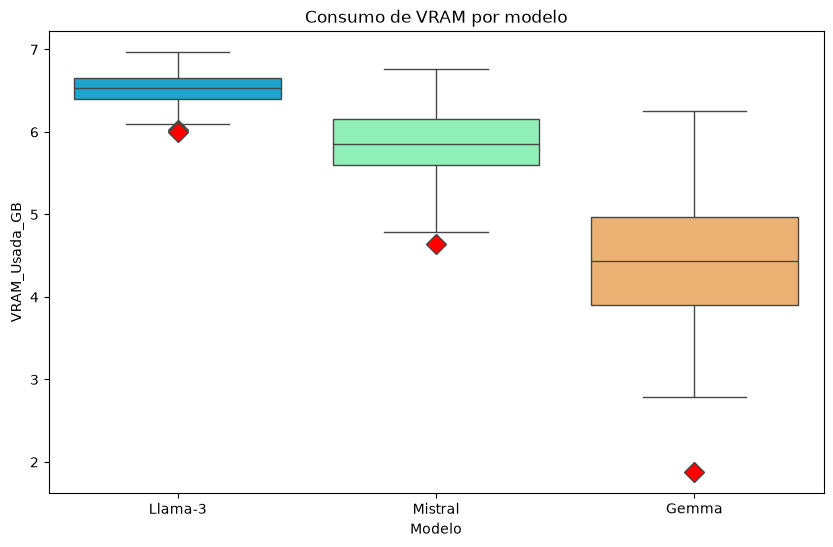

In [70]:
## Misión 1 (Boxplot): Consumo de Memoria.

# Crea un diagrama de caja para visualizar la distribución de VRAM_Usada_GB por cada Modelo.

# Destaca visualmente los valores atípicos (outliers) cambiando su color y forma.



plt.figure(figsize=(10,6))
plt.title('Consumo de VRAM por modelo')
sns.boxplot(data=df_ia, 
            x="Modelo", 
            y="VRAM_Usada_GB",
            hue="Modelo",
            palette="rainbow",
            flierprops={'marker': 'D', "markerfacecolor":'red', "markersize": 10})
plt.show()



C:\Users\UsuarioM\AppData\Local\Temp\ipykernel_13436\2999816523.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ia, x='Modelo', y='Tiempo_Inferencia_ms', inner='quartile', palette='icefire')


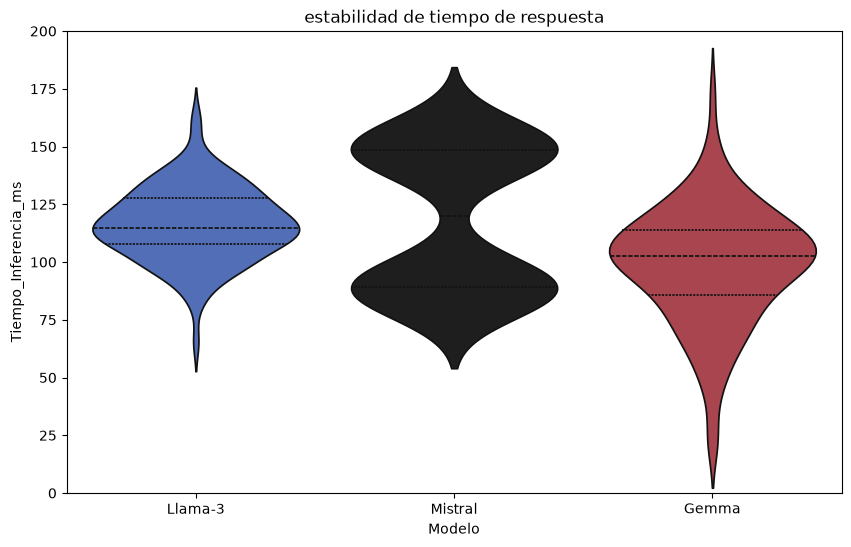

In [71]:
### Misión 2 (Violinplot): Estabilidad del Tiempo de Respuesta.

# Usa un diagrama de violín para analizar el Tiempo_Inferencia_ms de cada modelo.

# Dibuja las líneas de los cuartiles dentro del violín. (El gráfico revelará un comportamiento extraño en uno de los modelos).

plt.figure(figsize=(10,6))
plt.title('estabilidad de tiempo de respuesta')
sns.violinplot(data=df_ia, x='Modelo', y='Tiempo_Inferencia_ms', inner='quartile', palette='icefire')
plt.ylim(0,200)
plt.show()



                      Tiempo_Inferencia_ms  VRAM_Usada_GB  Puntuacion_Calidad
Tiempo_Inferencia_ms              1.000000       0.238044            0.077065
VRAM_Usada_GB                     0.238044       1.000000            0.047374
Puntuacion_Calidad                0.077065       0.047374            1.000000


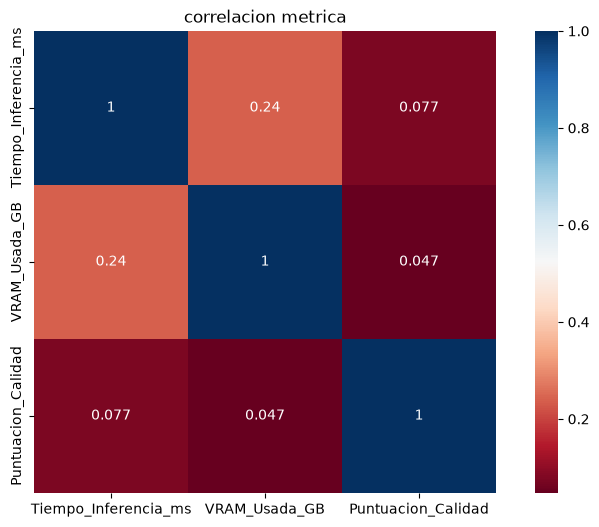

In [72]:
### Misión 3 (Heatmap): Correlación de Métricas.

# Calcula la matriz de correlación solo de las columnas numéricas.

# Crea un mapa de calor que muestre los valores numéricos, usando un mapa de color que diferencie valores positivos y negativos, y aplica forma cuadrada a las celdas.

# datos_ia_1 = {
#     "Tiempo_Inferencia_ms": np.concatenate([
#         np.random.normal(120, 15, 100),  # Llama (Consistente)
#         np.concatenate([np.random.normal(90, 5, 50), np.random.normal(150, 5, 50)]), # Mistral (Bimodal)
#         np.random.normal(100, 25, 100)   # Gemma (Muy disperso)
#     ]),
#     "VRAM_Usada_GB": np.concatenate([
#         np.random.normal(6.5, 0.2, 100),
#         np.random.normal(5.8, 0.4, 100),
#         np.random.normal(4.5, 0.8, 100)
#     ]),
#     "Puntuacion_Calidad": np.random.uniform(7, 10, 300)
# }
# df_ia1 = pd.DataFrame(datos_ia_1)

# matriz_correlacion = df_ia[["Tiempo_Inferencia_ms", "VRAM_Usada_GB", "Puntuacion_Calidad"]].corr()
matriz_correlacion = df_ia.corr(numeric_only=True)
print(matriz_correlacion)

plt.figure(figsize=(10,6))
plt.title('correlacion metrica')
sns.heatmap(data=matriz_correlacion, cmap='RdBu', annot=True, square=True)

plt.show()